In [1]:
import numpy as np
from tqdm import tqdm
import time
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# TORCH MODULES FOR METRICS COMPUTATION :
import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import MultilabelF1Score
from torchmetrics.classification import MultilabelAccuracy
from torch.optim.lr_scheduler import LambdaLR
import torch.nn.functional as F

MAIN_DIR = '/kaggle/input/cafa-6-protein-function-prediction'

class config:
    train_sequences_path = MAIN_DIR  + "/Train/train_sequences.fasta"
    train_labels_path = MAIN_DIR + "/Train/train_terms.tsv"
    test_sequences_path = MAIN_DIR + "/Test/testsuperset.fasta"
    
    num_labels = 500
    n_epochs = 5
    batch_size = 128
    lr = 0.01
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class ProteinSequenceDataset(Dataset):
    
    def __init__(self, train_emb, train_id, top, datatype):
        super(ProteinSequenceDataset).__init__()
        
        self.datatype = datatype
        embeds = np.load(train_emb)
        ids = np.load(train_id)
            
        embeds_list = []
        for l in range(embeds.shape[0]):
            embeds_list.append(embeds[l,:])
        self.df = pd.DataFrame(data={"EntryID": ids, "embed" : embeds_list})
        
        if datatype=="train":
            np_labels = np.load(top)
            df_labels = pd.DataFrame(self.df['EntryID'])
            df_labels['labels_vect']=[row for row in np_labels]
            self.df = self.df.merge(df_labels, on="EntryID")
            
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        embed = torch.tensor(self.df.iloc[index]["embed"] , dtype = torch.float32)
        if self.datatype=="train":
            targets = torch.tensor(self.df.iloc[index]["labels_vect"], dtype = torch.float32)
            return embed, targets
        if self.datatype=="test":
            id = self.df.iloc[index]["EntryID"]
            return embed, id

In [3]:
top = "/kaggle/input/cafa6top500/train_targets_top500.npy"

train_emb = f"/kaggle/input/esm-train-2-data/train_3b_embeddings.npy"
train_id = f"/kaggle/input/esm-train-2-data/train_3b_ids.npy"
test_emb = f"/kaggle/input/ems-2-cafa-6/test_3b_embeddings_temp.npy"
test_id = f"/kaggle/input/ems-2-cafa-6/test_3b_ids_temp.npy"

train_dataset_6 = ProteinSequenceDataset(train_emb, train_id, top, datatype="train")
test_dataset_6 = ProteinSequenceDataset(test_emb, test_id, top, datatype="test")

In [4]:
train_dataset_6

In [5]:
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=6, alpha= 6, dropout= 0.035, bias=True):
        super().__init__()
        self.r = r
        self.alpha = alpha if alpha is not None else r
        self.scaling = self.alpha / max(1, self.r)
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if r > 0:
            # low-rank matrices
            self.lora_A = nn.Parameter(torch.randn(r, in_features) * 0.01)
            self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        else:
            self.register_parameter('lora_A', None)
            self.register_parameter('lora_B', None)

    def forward(self, x):
        base = self.linear(x)
        if self.r > 0:
            # compute adapter output (initially 0 due to B = 0)
            x_d = self.dropout(x)
            a_out = F.linear(x_d, self.lora_A)       # (batch, r)
            b_out = F.linear(a_out, self.lora_B)     # (batch, out)
            return base + b_out * self.scaling
        else:
            return base

# 2. LoRA-Enhanced Hybrid Model
class HybridModel(nn.Module):
    """Hybrid model combining CNN and LSTM features with LoRA for safe fine-tuning"""

    def __init__(self, input_dim, num_classes, dropout_rate=0.3, lora_r=6, lora_alpha= 6, lora_dropout=0.035):
        super().__init__()

        # ----- CNN branch (unchanged) -----
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(128)

        # ----- LSTM branch (unchanged) -----
        self.lstm = nn.LSTM(input_dim, 256, num_layers=2,
                            bidirectional=True, dropout=dropout_rate, batch_first=True)

        # Optional small projection for LSTM output to apply LoRA safely
        self.lstm_proj = LoRALinear(512, 512, r=lora_r, alpha=lora_alpha, dropout=lora_dropout)

        # ----- Fusion and Classification (LoRA applied here) -----
        self.fc1 = LoRALinear(64 * 128 + 512, 512, r=lora_r, alpha=lora_alpha, dropout=lora_dropout)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = LoRALinear(512, 256, r=lora_r, alpha=lora_alpha, dropout=lora_dropout)
        self.fc3 = LoRALinear(256, num_classes, r=lora_r, alpha=lora_alpha, dropout=lora_dropout)

    def forward(self, x):
        batch_size = x.shape[0]

        # ----- CNN branch -----
        cnn_x = x.unsqueeze(1)           # (B, 1, seq_len)
        cnn_x = F.relu(self.conv1(cnn_x))
        cnn_x = F.relu(self.conv2(cnn_x))
        cnn_x = self.pool(cnn_x)
        cnn_x = cnn_x.view(batch_size, -1)

        # ----- LSTM branch -----
        lstm_x = x.unsqueeze(1)          # maintain consistency with original
        lstm_out, _ = self.lstm(lstm_x)
        lstm_x = lstm_out[:, -1, :]      # take final hidden state
        lstm_x = self.lstm_proj(lstm_x)  # safe LoRA projection

        # ----- Concatenate and classify -----
        combined = torch.cat([cnn_x, lstm_x], dim=1)

        x = F.relu(self.fc1(combined))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

def mark_only_lora_trainable(model):
    for name, param in model.named_parameters():
        param.requires_grad = False
    for module in model.modules():
        if isinstance(module, LoRALinear):
            if module.lora_A is not None:
                module.lora_A.requires_grad = True
            if module.lora_B is not None:
                module.lora_B.requires_grad = True

#Gaining LoRA parameters
def get_lora_params(model):
    return [p for p in model.parameters() if p.requires_grad]


In [6]:
class SmoothBCEWithLogitsLoss(nn.Module):
    def __init__(self, smoothing=0.0045):
        super().__init__()
        self.smoothing = smoothing
        self.loss = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        target = target * (1 - self.smoothing) + 0.5 * self.smoothing
        return self.loss(pred, target)

def get_scheduler(optimizer, config):
    def lr_lambda(current_step):
        warmup_steps = 8
        total_steps = config.n_epochs
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.1, 0.5 * (1.0 + np.cos(np.pi * progress)))
    return LambdaLR(optimizer, lr_lambda)

In [7]:
def train_model(model, train_size=0.9):
    train_set_6, val_set_6 = random_split(train_dataset_6, lengths = [int(len(train_dataset_6)*train_size), len(train_dataset_6)-int(len(train_dataset_6)*train_size)])
    train_dataloader_6 = torch.utils.data.DataLoader(train_set_6, batch_size=config.batch_size, shuffle=True)
    val_dataloader_6 = torch.utils.data.DataLoader(val_set_6, batch_size=config.batch_size, shuffle=True)

    mark_only_lora_trainable(model)
    lora_params = get_lora_params(model)
    
    optimizer = torch.optim.AdamW(lora_params, lr=config.lr * 0.5, weight_decay= 4.4e-4)
    scheduler = get_scheduler(optimizer, config)
    CrossEntropy = SmoothBCEWithLogitsLoss(smoothing= 0.0045)
    f1_score = MultilabelF1Score(num_labels=config.num_labels, average='micro').to(config.device)
    n_epochs = config.n_epochs

    print("BEGIN TRAINING WITH ESM2 EMBEDDINGS...")
    train_loss_history=[]
    val_loss_history=[]
    
    train_f1score_history=[]
    val_f1score_history=[]
    for epoch in range(n_epochs):
        print("EPOCH ", epoch+1)
        ## TRAIN PHASE :
        losses = []
        scores = []
        
        for embed, targets in tqdm(train_dataloader_6):
            embed, targets = embed.to(config.device), targets.to(config.device)
            optimizer.zero_grad()
            preds = model(embed)
            loss= CrossEntropy(preds, targets)
            score=f1_score(preds, targets)
            losses.append(loss.item()) 
            scores.append(score.item())
            loss.backward()
            optimizer.step()
            
        avg_loss = np.mean(losses)
        avg_score = np.mean(scores)
        print("Running Average TRAIN Loss : ", avg_loss)
        print("Running Average TRAIN F1-Score : ", avg_score)
        train_loss_history.append(avg_loss)
        train_f1score_history.append(avg_score)
        
        ## VALIDATION PHASE : 
        losses = []
        scores = []
        for embed, targets in val_dataloader_6:
            embed, targets = embed.to(config.device), targets.to(config.device)
            preds = model(embed)
            loss= CrossEntropy(preds, targets)
            score=f1_score(preds, targets)
            losses.append(loss.item())
            scores.append(score.item())
            
        avg_loss = np.mean(losses)
        avg_score = np.mean(scores)
        print("Running Average VAL Loss : ", avg_loss)
        print("Running Average VAL F1-Score : ", avg_score)
        val_loss_history.append(avg_loss)
        val_f1score_history.append(avg_score)
        
        scheduler.step(avg_loss)
        print("\n")
        
    print("TRAINING FINISHED")
    print("FINAL TRAINING SCORE : ", train_f1score_history[-1])
    print("FINAL VALIDATION SCORE : ", val_f1score_history[-1])
    
    losses_history = {"train" : train_loss_history, "val" : val_loss_history}
    scores_history = {"train" : train_f1score_history, "val" : val_f1score_history}
    
    return model, losses_history, scores_history

model = HybridModel(2560, config.num_labels, 
                    dropout_rate= 0.275, lora_r= 6, 
                    lora_alpha= 6, lora_dropout=0.1).to(config.device)

esm2_model, esm2_losses, esm2_scores = train_model(model)

BEGIN TRAINING WITH ESM2 EMBEDDINGS...
EPOCH  1


100%|██████████| 580/580 [00:13<00:00, 43.34it/s]


Running Average TRAIN Loss :  0.6938873323900946
Running Average TRAIN F1-Score :  0.014120641442272684
Running Average VAL Loss :  0.6938803938718943
Running Average VAL F1-Score :  0.014138650937149158


EPOCH  2


100%|██████████| 580/580 [00:12<00:00, 46.52it/s]


Running Average TRAIN Loss :  0.06811247308706415
Running Average TRAIN F1-Score :  0.058257242064152295
Running Average VAL Loss :  0.0445960018497247
Running Average VAL F1-Score :  0.029672099492297724


EPOCH  3


...

Running Average TRAIN Loss :  0.04464719860075877
Running Average TRAIN F1-Score :  0.03861756529739319
Running Average VAL Loss :  0.04445406192770371
Running Average VAL F1-Score :  0.040352203181156746


EPOCH  4


100%|██████████| 580/580 [00:12<00:00, 46.34it/s]


Running Average TRAIN Loss :  0.04459763896362535
Running Average TRAIN F1-Score :  0.039602475173386005
Running Average VAL Loss :  0.04447172524837347
Running Average VAL F1-Score :  0.03756602654376855


EPOCH  5


100%|██████████| 580/580 [00:12<00:00, 46.13it/s]


Running Average TRAIN Loss :  0.04451140908460165
Running Average TRAIN F1-Score :  0.03748883318541379
Running Average VAL Loss :  0.04437704263971402
Running Average VAL F1-Score :  0.038899998223552334


TRAINING FINISHED
FINAL TRAINING SCORE :  0.03748883318541379
FINAL VALIDATION SCORE :  0.038899998223552334


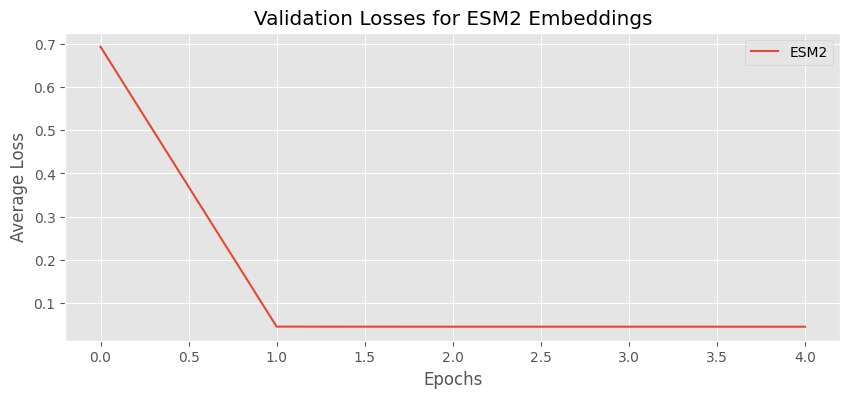

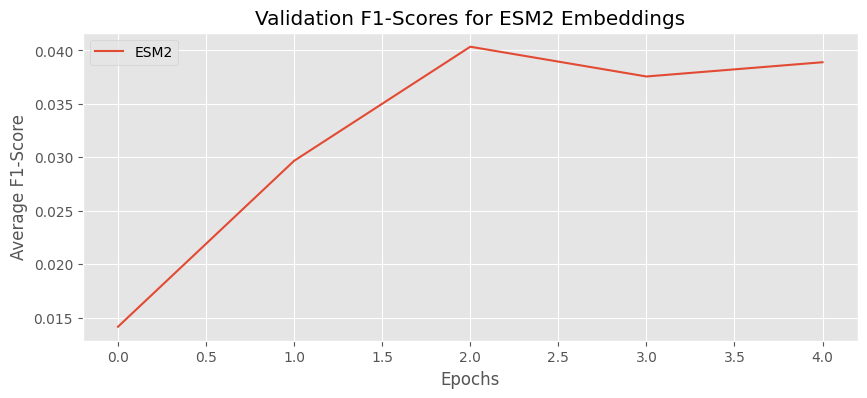

In [8]:
plt.figure(figsize = (10, 4))
plt.plot(esm2_losses["val"], label = "ESM2") 
plt.title("Validation Losses for ESM2 Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average Loss")
plt.legend()
plt.show()

plt.figure(figsize = (10, 4))
plt.plot(esm2_scores["val"], label = "ESM2")
plt.title("Validation F1-Scores for ESM2 Embeddings")
plt.xlabel("Epochs")
plt.ylabel("Average F1-Score")
plt.legend()
plt.show()

In [9]:
def predict(test_dataset):
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    # Get label names
    labels_df = pd.read_csv(config.train_labels_path, sep="\t", names=["EntryID", "term", "aspect"])
    top_terms = labels_df.groupby("term")["EntryID"].count().sort_values(ascending=False)
    label_names = top_terms[:config.num_labels].index.tolist()
    
    # Generate predictions
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for embeddings, protein_id in tqdm(test_loader, desc="Predicting"):
            embeddings = embeddings.to(config.device)
            outputs = torch.sigmoid(model(embeddings)).cpu().numpy().squeeze()
            
            for i, conf in enumerate(outputs):
                if conf > 0.05:  # Only include predictions above threshold
                    predictions.append({
                        'Id': protein_id[0],
                        'GO term': label_names[i],
                        'Confidence': min(conf, 0.95)  # Scientific standard
                    })
    
    return pd.DataFrame(predictions)

submission_df = predict(test_dataset_6)
submission_df.to_csv('submission.tsv', sep='\t', header=False, index=False)

Predicting: 100%|██████████| 222000/222000 [08:54<00:00, 415.56it/s]
